In [1]:
import radarsimpy

print("`RadarSimPy` used in this example is version: " + str(radarsimpy.__version__))

`RadarSimPy` used in this example is version: 15.2.0


# Stripmap SAR Imaging with a Linear FM (LFM) Chirp Waveform

A **Linear Frequency Modulated (LFM) chirp** sweeps the transmit frequency linearly over the pulse duration, decoupling **range resolution** from **pulse energy**. Unlike a simple rectangular pulse (where resolution and pulse width are locked together), a chirp of bandwidth $B$ and duration $\tau$ achieves range resolution $\Delta R = c/(2B)$ while carrying a **time-bandwidth product** $B\tau \gg 1$, giving a matched-filter **processing gain** of $10\log_{10}(B\tau)$ dB. This is the waveform used by virtually all real airborne and spaceborne stripmap SAR systems.

This notebook follows the structure of the MathWorks [*Stripmap Synthetic Aperture Radar (SAR) Image Formation*](https://www.mathworks.com/help/radar/ug/stripmap-synthetic-aperture-radar-sar-image-formation.html) example — C-band carrier, 50 MHz LFM sweep, PRF 1 kHz, 100 m/s platform, three point targets at 800 / 1000 / 1300 m — reproduced end-to-end with [RadarSimPy](https://radarsimx.com).

## Key Concepts

| Quantity | Formula | This example |
|---|---|---|
| Range resolution | $$\Delta R = c/(2B)$$ | 3 m (B = 50 MHz) |
| Time-bandwidth product | $$B\tau$$ | 150 (τ = 3 μs) |
| Matched-filter gain | $$10\log_{10}(B\tau)$$ | ≈ 21.8 dB |
| SAR azimuth resolution | $$\Delta_{az} = D_a/2$$ | 0.5 m ($D_a$ = 1 m antenna) |
| Synthetic aperture length | $$L_s = \lambda R / D_a$$ | 75 m (theoretical) |

> **Why LFM instead of a rectangular pulse?** A rectangular pulse ties range resolution directly to pulse width ($\Delta R = c\tau/2$), forcing a trade-off between resolution and transmitted energy (and thus SNR). An LFM chirp transmits a *long* pulse (more energy) but is compressed on receive to a *short* effective pulse (fine resolution) — the compression ratio is exactly the time-bandwidth product $B\tau$.

## RadarSimPy LFM Receiver Model

RadarSimPy simulates the receiver for a chirp transmitter (`f=[f_start, f_stop]`) using a **stretch/deramp architecture**, identical in spirit to the range processing already used in the FMCW notebooks: each pulse's recorded baseband is a short **beat-tone** signal (length = chirp duration × sample rate) whose frequency directly encodes the two-way range,

$$R = f_{beat}\, \frac{c\,\tau}{2B}$$

rather than a long raw echo requiring a time-domain matched filter. Range compression is therefore a simple **FFT along fast-time** — exactly like FMCW range processing — instead of a chirp-replica correlation.

## Workflow

```
LFM waveform design → Transmitter / Receiver → Scene & Trajectory → sim_radar()
    → Range Compression (fast-time FFT) → Back-Projection (azimuth focus) → SAR image
```

## Setup

In [2]:
import numpy as np
import scipy
from scipy import constants
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from IPython.display import Image, display
from radarsimpy import Radar, Transmitter, Receiver
from radarsimpy.simulator import sim_radar

# Set to True for interactive plots; False renders a static JPEG (e.g. for HTML export)
INTERACTIVE = False


def show(fig):
    if INTERACTIVE:
        fig.show()
    else:
        display(Image(fig.to_image(format="jpg", scale=2)))

### Waveform, Platform, and Sampling Parameters

The radar operates in **C-band** (4 GHz) with a **50 MHz LFM sweep**, giving a 3 m range resolution. The platform flies at 100 m/s and the reference (broadside) target range is 1000 m.

> **Sample rate note:** because RadarSimPy's chirp receiver model reports range via an *absolute* beat frequency (see intro), the sample rate `fs` must be high enough to keep the beat frequency for the *farthest* target under the Nyquist limit — not just fast enough for the 50 MHz sweep bandwidth itself. The required rate is
> $$ f_s > \frac{4 R_{max} B}{c\,\tau} $$
> which is computed explicitly below.

In [3]:
c = constants.c  # Speed of light (m/s)

# Carrier / LFM waveform
fc = 4e9  # Carrier frequency (Hz) - C-band
lam = c / fc  # Wavelength (m)
bw = 50e6  # LFM sweep bandwidth (Hz)  →  ΔR = c/(2B) = 3 m
tpd = 3e-6  # Chirp (pulse) duration (s)
prf = 1000  # Pulse repetition frequency (Hz)
prp = 1 / prf  # Pulse repetition period (s)
tx_power_dbm = 40  # Transmit power (dBm)
num_pulses = 300  # Number of pulses → Ls = v*num_pulses/prf = 30 m synthetic aperture

# Platform / geometry
v_platform = 100.0  # Along-track velocity (m/s)
r0 = 1000.0  # Broadside reference range (m)
r_max_expected = 1350.0  # Farthest range of interest (targets + margin), for fs sizing

# Derived waveform quantities
range_res = c / (2 * bw)
bt_product = bw * tpd  # Time-bandwidth product
mf_gain_db = 10 * np.log10(bt_product)  # Matched-filter / pulse-compression gain

# Sample rate: must satisfy fs > 4*R_max*B/(c*tau) to avoid beat-frequency aliasing
# (RadarSimPy's chirp receiver reports range via an absolute beat frequency - see intro)
fs_min = 4 * r_max_expected * bw / (c * tpd)
fs = 400e6  # Chosen with margin above fs_min
pulse_samples = int(tpd * fs)  # Fast-time samples per pulse (dechirped beat-tone record)
range_period = fs * c * tpd / (2 * bw)  # Unambiguous absolute-range span at this fs

# Antenna / synthetic aperture
Da = 1.0  # Real antenna azimuth dimension (m)
az_res_sar = Da / 2  # Theoretical SAR azimuth resolution = D_a/2
synthetic_aperture_theory = lam * r0 / Da  # Full theoretical aperture length Ls

# Achieved values for the truncated aperture actually simulated (num_pulses)
aperture_time = num_pulses / prf
synthetic_aperture = v_platform * aperture_time
az_res_achieved = lam * r0 / (2 * synthetic_aperture)

print(f"fc={fc/1e9:.0f} GHz  B={bw/1e6:.0f} MHz  τ={tpd*1e6:.1f} μs  PRF={prf} Hz")
print(f"ΔR={range_res:.1f} m   Bτ={bt_product:.0f}   MF gain={mf_gain_db:.1f} dB")
print(f"fs_min={fs_min/1e6:.1f} MHz  →  fs={fs/1e6:.0f} MHz  ({pulse_samples} samples/pulse)")
print(f"Unambiguous range span at this fs: {range_period:.0f} m")
print(f"Da={Da:.1f} m  →  Δaz(theory)={az_res_sar:.2f} m  Ls(theory)={synthetic_aperture_theory:.0f} m")
print(f"Simulated aperture: {num_pulses} pulses → Ls={synthetic_aperture:.1f} m  Δaz(achieved)≈{az_res_achieved:.2f} m")

fc=4 GHz  B=50 MHz  τ=3.0 μs  PRF=1000 Hz
ΔR=3.0 m   Bτ=150   MF gain=21.8 dB
fs_min=300.2 MHz  →  fs=400 MHz  (1200 samples/pulse)
Unambiguous range span at this fs: 3598 m
Da=1.0 m  →  Δaz(theory)=0.50 m  Ls(theory)=75 m
Simulated aperture: 300 pulses → Ls=30.0 m  Δaz(achieved)≈1.25 m


### Transmitter, Receiver & Radar Object

The **LFM chirp** is defined directly through the `f`/`t` waveform arguments: `f=[fc-B/2, fc+B/2]` sweeps linearly from the low to the high edge of the band over `t=[0, τ]`. No amplitude/phase modulation arrays are needed — the chirp itself defines the "on" portion of each PRP, with the remainder of the PRP idle (matching a real pulsed radar's transmit/listen duty cycle).

The antenna beam is modelled with wide raised-cosine tapers (azimuth $\cos^{8}(\theta)$, elevation $\cos^{40}(\phi)$) — wide enough to keep every target illuminated across the full simulated 30 m synthetic aperture, at 20 dBi peak gain. The receiver samples at `fs` = 400 MHz, sized above (not by the 50 MHz sweep bandwidth alone, but by the requirement to keep the absolute-range beat frequency unambiguous — see the parameter cell above).

In [4]:
# ── Antenna pattern ────────────────────────────────────────────────────────────
antenna_gain = 20  # dBi

# Azimuth: wide cos^8 taper — keeps targets illuminated across the whole aperture
az_angle = np.arange(-60, 61, 1)
az_pattern = 20 * np.log10(np.abs(np.cos(az_angle / 180 * np.pi)) ** 8) + antenna_gain

# Elevation: cos^40 taper — narrower beam out of the imaging plane
el_angle = np.arange(-30, 31, 1)
el_pattern = 20 * np.log10(np.abs(np.cos(el_angle / 180 * np.pi)) ** 40) + antenna_gain

tx_channel = dict(
    location=(0, 0, 0),
    azimuth_angle=az_angle,
    azimuth_pattern=az_pattern,
    elevation_angle=el_angle,
    elevation_pattern=el_pattern,
)

# ── LFM chirp waveform: f sweeps [fc-B/2, fc+B/2] over t=[0, τ]; idle for the rest of the PRP
tx = Transmitter(
    f=[fc - bw / 2, fc + bw / 2],
    t=[0, tpd],
    tx_power=tx_power_dbm,
    pulses=num_pulses,
    prp=prp,
    channels=[tx_channel],
)

print("Transmitter configured.")
print(f"  Chirp: {(fc-bw/2)/1e9:.4f} → {(fc+bw/2)/1e9:.4f} GHz over {tpd*1e6:.1f} μs")
print(f"  Duty cycle: {tpd/prp*100:.2f}%")

Transmitter configured.
  Chirp: 3.9750 → 4.0250 GHz over 3.0 μs
  Duty cycle: 0.30%


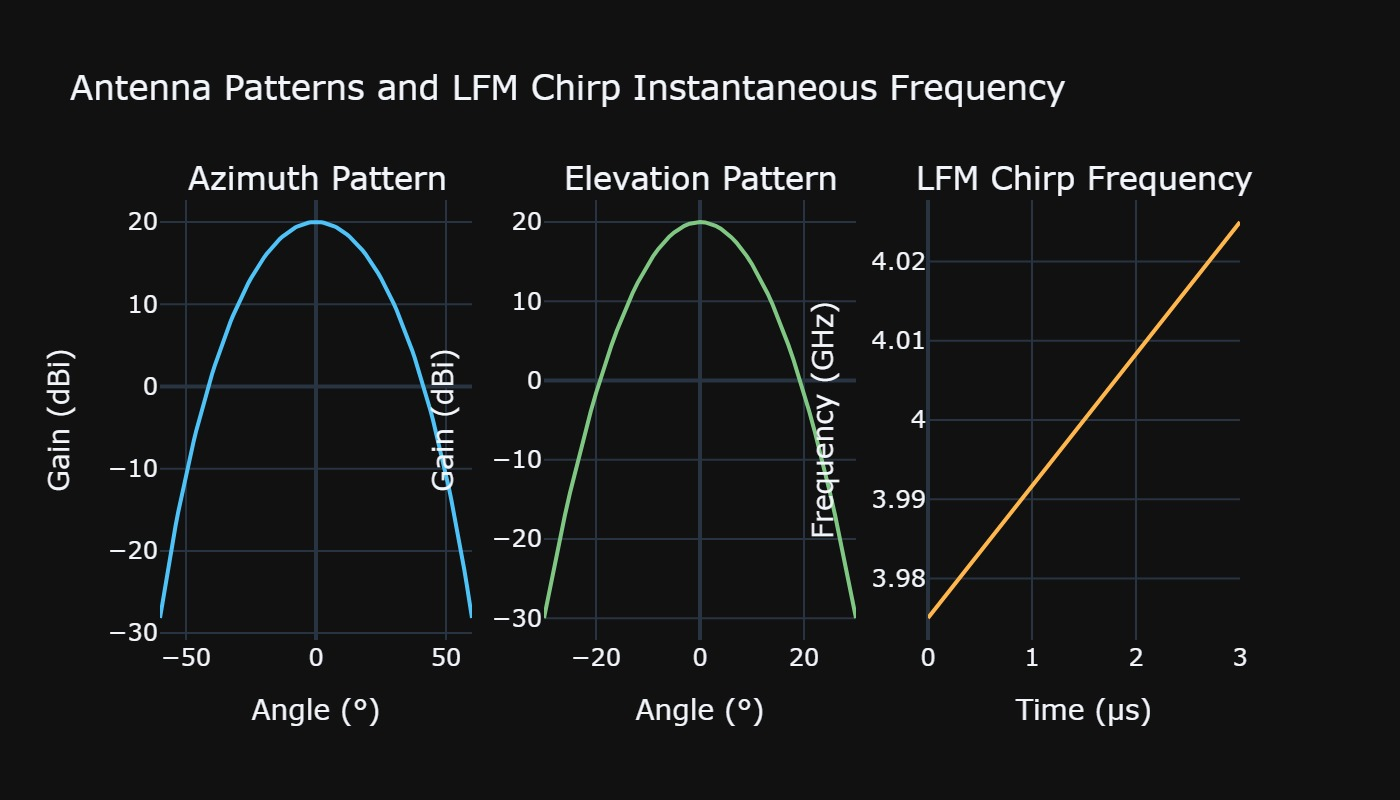

In [5]:
t_chirp = np.linspace(0, tpd, 500)
inst_freq_ghz = (fc + (bw / tpd) * (t_chirp - tpd / 2)) / 1e9  # instantaneous frequency

fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=("Azimuth Pattern", "Elevation Pattern", "LFM Chirp Frequency"),
)

fig.add_trace(
    go.Scatter(x=az_angle, y=az_pattern, line=dict(color="#4FC3F7", width=2)),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(x=el_angle, y=el_pattern, line=dict(color="#81C784", width=2)),
    row=1,
    col=2,
)
fig.add_trace(
    go.Scatter(
        x=t_chirp * 1e6,
        y=inst_freq_ghz,
        line=dict(color="#FFB74D", width=2),
    ),
    row=1,
    col=3,
)

fig.update_xaxes(title_text="Angle (°)", row=1, col=1)
fig.update_xaxes(title_text="Angle (°)", row=1, col=2)
fig.update_xaxes(title_text="Time (µs)", row=1, col=3)
fig.update_yaxes(title_text="Gain (dBi)", row=1, col=1)
fig.update_yaxes(title_text="Gain (dBi)", row=1, col=2)
fig.update_yaxes(title_text="Frequency (GHz)", row=1, col=3)

fig.update_layout(
    title="Antenna Patterns and LFM Chirp Instantaneous Frequency",
    template="plotly_dark",
    height=400,
    showlegend=False,
)
show(fig)

In [6]:
rx_channel = dict(
    location=(0, 0, 0),
    azimuth_angle=az_angle,
    azimuth_pattern=az_pattern,
    elevation_angle=el_angle,
    elevation_pattern=el_pattern,
)

rx = Receiver(
    fs=fs,
    noise_figure=5,  # NF = 5 dB
    rf_gain=20,  # LNA gain = 20 dB
    baseband_gain=30,  # Baseband gain = 30 dB
    channels=[rx_channel],
)

print("Receiver configured.")
print(f"  Sample rate      : {fs/1e6:.0f} MHz")
print(f"  Samples per pulse: {pulse_samples}")

Receiver configured.
  Sample rate      : 400 MHz
  Samples per pulse: 1200


### Platform Trajectory & Scene

The platform flies straight and level along +x at $v = 100\text{ m/s}$, passing broadside to the scene at $x=0$. Following the MathWorks stripmap SAR example, three point targets are placed at ranges 800 m, 1000 m, and 1300 m:

| Target | Along-track x (m) | Range y (m) | RCS (dBsm) | Purpose |
|--------|--------------------|-------------|------------|---------|
| A | 0 | 800 | 0 | Range resolution test (below reference) |
| B | 0 | 1000 | 5 | Broadside reference target (aperture centre) |
| C | +8 | 1300 | 10 | Range test (above reference) + azimuth offset |

Targets A and B, and B and C, are separated by 200–300 m in range — far beyond the 3 m range resolution. Target C is additionally offset 8 m in azimuth from B, well beyond the achieved azimuth resolution, to test 2-D focusing.

In [7]:
# Platform flies along +x; aperture centred at x = 0
pulse_times = np.arange(num_pulses) * prp
pulse_times -= pulse_times.mean()
platform_x = v_platform * pulse_times  # along-track positions (m)

In [8]:
radar = Radar(
    transmitter=tx,
    receiver=rx,
)

# Centre the aperture at x = 0 by subtracting the mid-aperture time offset,
# so the simulated platform positions match the centred platform_x used in the BPA.
t_offset = (num_pulses - 1) / 2 * prp
locations = [(radar.time_prop["timestamp"] - t_offset) * v_platform, 0, 0]

radar.set_motion(location=locations, rotation=[90, 0, 0])

print(f"Radar created with {num_pulses} pulses.")
print(f"  Platform x: {locations[0].ravel()[0]:.1f} m  →  {locations[0].ravel()[-1]:.1f} m")

Radar created with 300 pulses.
  Platform x: -14.9 m  →  15.0 m


In [9]:
targets = [
    {"location": (0.0, 800.0, 0.0), "rcs": 0.0, "phase": 0.0},  # A: range test (below)
    {"location": (0.0, r0, 0.0), "rcs": 5.0, "phase": 0.0},  # B: broadside reference
    {"location": (8.0, 1300.0, 0.0), "rcs": 10.0, "phase": 0.0},  # C: range + azimuth test
]

print("Targets:")
for i, t in enumerate(targets):
    x, y, z = t["location"]
    slant = np.hypot(y, x)
    print(
        f"  Target {chr(65+i)}: x={x:+.1f} m, y={y:.0f} m  "
        f"(slant R ≈ {slant:.1f} m)  RCS = {t['rcs']} dBsm"
    )

Targets:
  Target A: x=+0.0 m, y=800 m  (slant R ≈ 800.0 m)  RCS = 0.0 dBsm
  Target B: x=+0.0 m, y=1000 m  (slant R ≈ 1000.0 m)  RCS = 5.0 dBsm
  Target C: x=+8.0 m, y=1300 m  (slant R ≈ 1300.0 m)  RCS = 10.0 dBsm


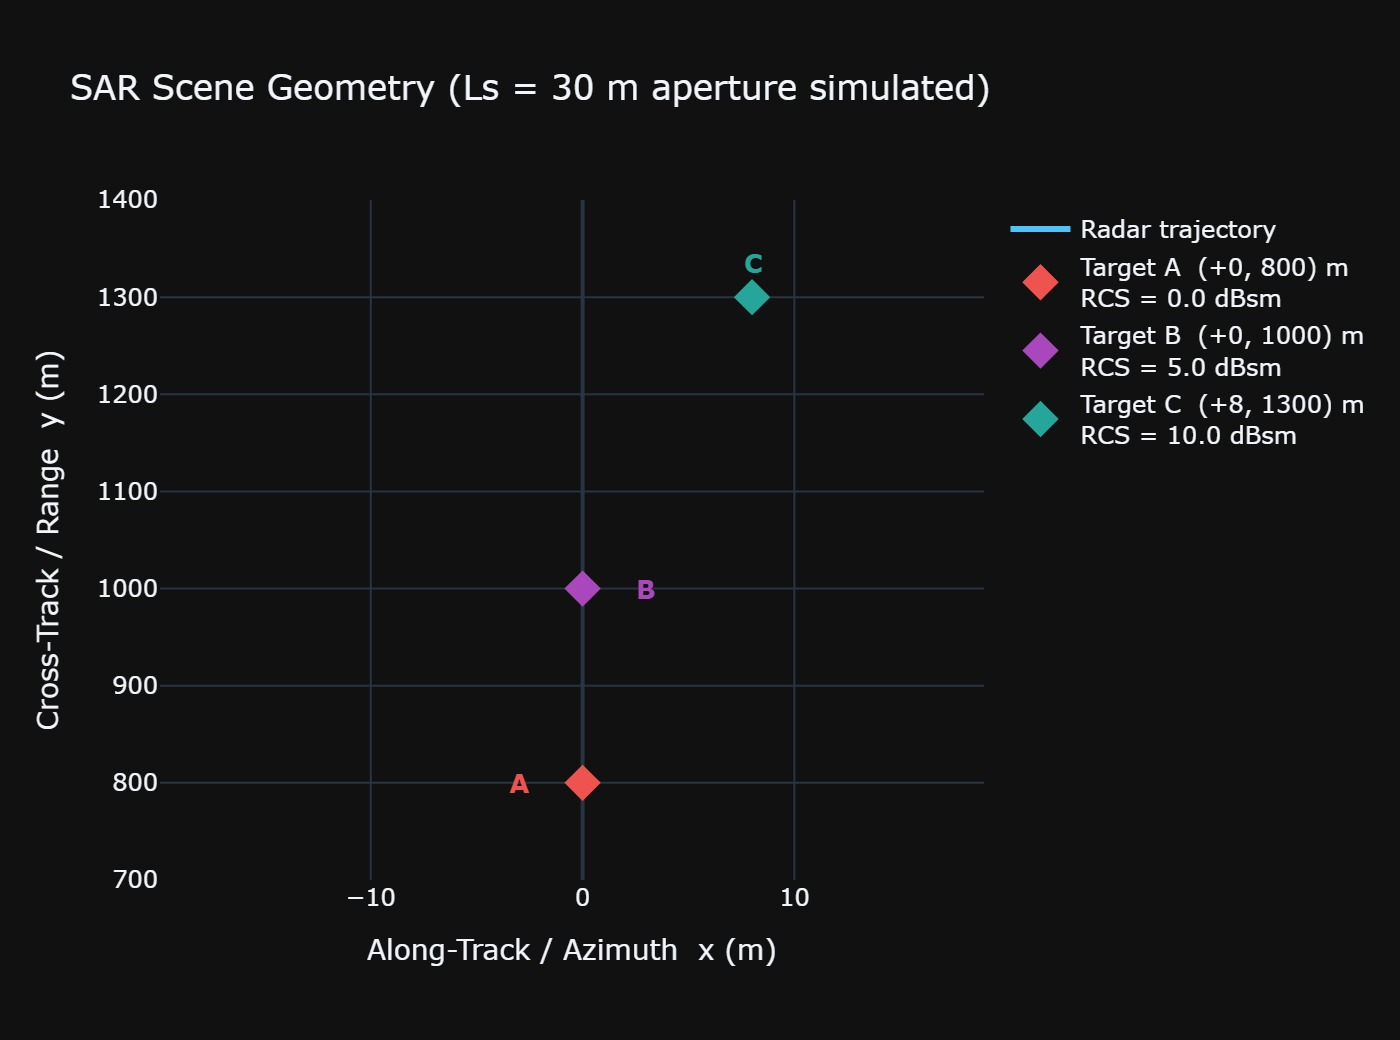

In [10]:
# ── Scene geometry visualisation ──────────────────────────────────────────────
fig_geo = go.Figure()
target_colors = ["#EF5350", "#AB47BC", "#26A69A"]

fig_geo.add_trace(
    go.Scatter(
        x=platform_x,
        y=np.zeros_like(platform_x),
        mode="lines",
        line=dict(color="#4FC3F7", width=3),
        name="Radar trajectory",
    )
)
fig_geo.add_trace(
    go.Scatter(
        x=[platform_x[0], platform_x[-1]],
        y=[0, 0],
        mode="markers",
        marker=dict(size=9, color="#4FC3F7", symbol=["circle-open", "circle"]),
        showlegend=False,
    )
)

for tgt, lbl, col in zip(targets, ["A", "B", "C"], target_colors):
    xt, yt, _ = tgt["location"]
    fig_geo.add_trace(
        go.Scatter(
            x=[xt],
            y=[yt],
            mode="markers",
            marker=dict(size=14, color=col, symbol="diamond"),
            name=f"Target {lbl}  ({xt:+.0f}, {yt:.0f}) m<br>RCS = {tgt['rcs']} dBsm",
        )
    )
    offsets = {"A": (-32, 0), "B": (32, 0), "C": (0, 18)}
    ox, oy = offsets[lbl]
    fig_geo.add_annotation(
        x=xt,
        y=yt,
        text=f"<b>{lbl}</b>",
        font=dict(color=col, size=13),
        showarrow=False,
        xshift=ox,
        yshift=oy,
    )

fig_geo.update_layout(
    title=f"SAR Scene Geometry (Ls = {synthetic_aperture:.0f} m aperture simulated)",
    xaxis_title="Along-Track / Azimuth  x (m)",
    yaxis_title="Cross-Track / Range  y (m)",
    template="plotly_dark",
    height=520,
    legend=dict(x=1.02, y=1, xanchor="left", yanchor="top", bgcolor="rgba(0,0,0,0)"),
    xaxis=dict(range=[platform_x[0] - 5, max(platform_x[-1], 12) + 4]),
    yaxis=dict(range=[700, 1400]),
)
show(fig_geo)

## Simulation & SAR Processing

`sim_radar` propagates the LFM chirp to each scatterer and returns the **complex baseband signal** `baseband[rx_channel, pulse_index, sample_index]`. For a chirp transmitter, each pulse's baseband record is the **dechirped beat-tone** signal described in the introduction — its length equals the chirp duration times the sample rate, not the full PRP.

SAR processing has the same two stages as before, but range compression now uses **fast-time FFT** instead of a time-domain matched filter:

1. **Range Compression (Fast-Time FFT)** — an FFT of each pulse's beat-tone record directly produces the range profile; the FFT frequency axis is converted to range via $R = f\,c\tau/(2B)$. This is mathematically equivalent to matched filtering an LFM chirp, but computed via the receiver's built-in deramp mixing rather than an explicit correlation.

2. **Back-Projection Algorithm (BPA)** — unchanged from the general SAR imaging approach: for each pixel $(x_p, y_p)$, compute the two-way range $R_n$ to the platform at pulse $n$, extract the range-compressed sample at that range, apply the phase correction $e^{-j4\pi R_n/\lambda}$, and coherently sum over all pulses:

$$I(x_p, y_p) = \sum_{n=0}^{N-1} S_{n}\left(R_n\right)\, e^{-j4\pi R_n/\lambda}$$

In [11]:
data = sim_radar(radar, targets, density=1)

baseband = data["baseband"]  # complex I/Q: (rx_ch, pulses, beat-tone samples)

print("Simulation complete.")
print(f"  baseband shape : {baseband.shape}")
print(f"    dim 0 : {baseband.shape[0]} RX channel(s)")
print(f"    dim 1 : {baseband.shape[1]} pulses (synthetic aperture)")
print(f"    dim 2 : {baseband.shape[2]} beat-tone samples per pulse")

Simulation complete.
  baseband shape : (1, 300, 1200)
    dim 0 : 1 RX channel(s)
    dim 1 : 300 pulses (synthetic aperture)
    dim 2 : 1200 beat-tone samples per pulse


### Step 1: Range Compression (Fast-Time FFT)

A **Dolph-Chebyshev window** (−50 dB design sidelobe level) is applied across fast-time before the FFT to suppress range sidelobes — the LFM equivalent of windowing a matched filter. The FFT output is converted from frequency to range using $R = f\,c\tau/(2B)$, then restricted to a window around the scene (700–1400 m) for efficient Back-Projection.


In [ ]:
raw = baseband[0, :, :]  # single RX channel: (num_pulses, pulse_samples)

# ── Fast-time window + FFT range compression ─────────────────────────────────
range_win = scipy.signal.windows.chebwin(pulse_samples, at=50)
NFFT = pulse_samples * 8  # 8× zero-padding → ~8× finer range grid
range_profile_full = np.fft.fftshift(
    np.fft.fft(raw * range_win[np.newaxis, :], NFFT, axis=1), axes=1
)
freq_axis = np.fft.fftshift(np.fft.fftfreq(NFFT, d=1 / fs))
range_axis_full = freq_axis * c * tpd / (2 * bw)

# ── Restrict to the scene window for efficient Back-Projection ───────────────
range_window_lo, range_window_hi = 700.0, 1400.0
range_mask = (range_axis_full >= range_window_lo) & (range_axis_full <= range_window_hi)
range_axis = range_axis_full[range_mask]
range_profile = range_profile_full[:, range_mask]

print(f"Range compression complete.  Range axis: {range_axis[0]:.1f} to {range_axis[-1]:.1f} m")
print(f"  Range bins kept: {range_profile.shape[1]} (of {pulse_samples} total)")
print(f"  Range resolution after compression: {range_res:.2f} m")

Range compression complete.  Range axis: 700.0 to 1399.7 m
  Range bins kept: 1868 (of 1200 total)
  Range resolution after compression: 3.00 m


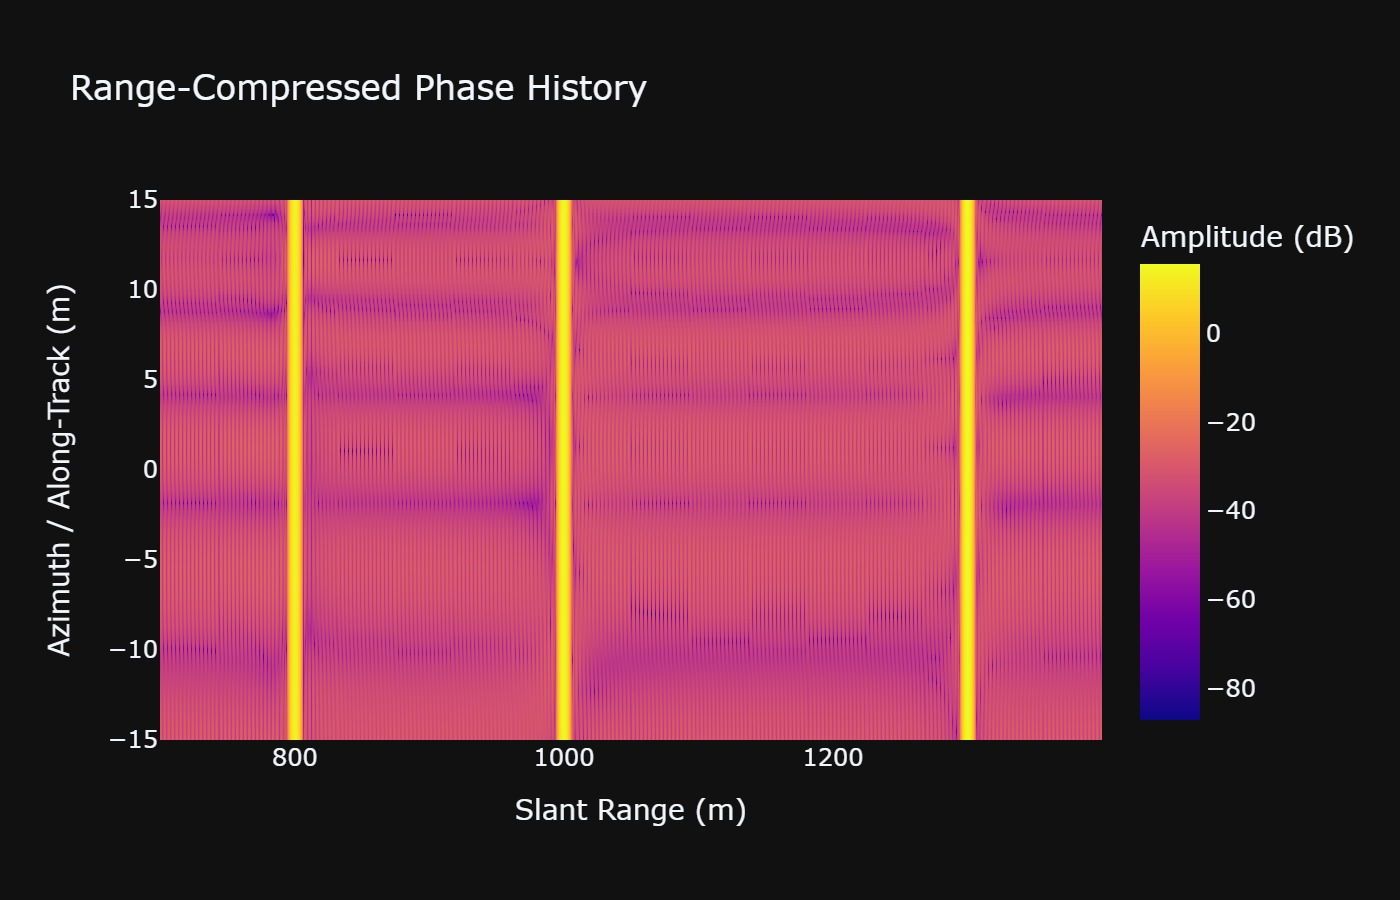

In [19]:
fig = go.Figure()
fig.add_trace(
    go.Heatmap(
        x=range_axis,
        y=platform_x,
        z=20 * np.log10(np.abs(range_profile) + 1e-12),
        colorscale="Plasma",
        colorbar=dict(title="Amplitude (dB)"),
    )
)
fig.update_layout(
    title="Range-Compressed Phase History",
    xaxis_title="Slant Range (m)",
    yaxis_title="Azimuth / Along-Track (m)",
    template="plotly_dark",
    height=450,
)
show(fig)

### Step 2: Back-Projection Focusing

Each target's hyperbolic range-walk trajectory across the aperture is visible above. Back-Projection coherently sums the range-compressed samples along each target's true range history, using a **Taylor window** (−55 dB design sidelobe level, $\bar n=4$) across the aperture to suppress azimuth sidelobes at the cost of ≈1.5× broadening of the azimuth main lobe.

In [20]:
from scipy.interpolate import interp1d
# ── Image grid ────────────────────────────────────────────────────────────────
range_pad = 60  # ± range padding around the 800-1300 m target swath
img_ranges = np.arange(800 - range_pad, 1300 + range_pad + range_res / 2, range_res / 2)

az_window = 25  # ± azimuth padding (m)
az_step = az_res_achieved / 2  # 2× oversampled
img_az = np.arange(-az_window, az_window + az_step, az_step)

print(f"Image grid: {len(img_az)} az × {len(img_ranges)} range pixels")
print(f"  Azimuth : {img_az[0]:.1f} to {img_az[-1]:.1f} m  (step {az_step:.2f} m)")
print(f"  Range   : {img_ranges[0]:.1f} to {img_ranges[-1]:.1f} m  (step {range_res/2:.2f} m)")

# ── Aperture tapering window ───────────────────────────────────────────────────
az_taper = scipy.signal.windows.taylor(num_pulses, nbar=4, sll=55)  # −55 dB Taylor

# ── Back-projection ────────────────────────────────────────────────────────────
sar_image = np.zeros((len(img_az), len(img_ranges)), dtype=complex)
for pulse_idx in range(num_pulses):
    x_n = platform_x[pulse_idx]
    w_n = az_taper[pulse_idx]  # ← aperture weight for this pulse
    dx = img_az[np.newaxis, :] - x_n
    dy = img_ranges[:, np.newaxis]
    R_n = np.sqrt(dx**2 + dy**2)
    interp_fn = interp1d(range_axis, range_profile[pulse_idx], kind='linear',
                     bounds_error=False, fill_value=0)
    interp_sig = interp_fn(R_n.ravel()).reshape(R_n.shape)
    phase_corr = np.exp(-1j * 4.0 * np.pi * R_n / lam)
    sar_image += w_n * (interp_sig * phase_corr).T  # ← weighted accumulation

print("Back-projection complete.")
print(f"  SAR image shape : {sar_image.shape}  (Naz × Nr)")

Image grid: 82 az × 415 range pixels
  Azimuth : -25.0 to 25.6 m  (step 0.62 m)
  Range   : 740.0 to 1360.6 m  (step 1.50 m)
Back-projection complete.
  SAR image shape : (82, 415)  (Naz × Nr)


## Results: Focused SAR Image

The focused image is displayed as **normalised power in dB** relative to the peak pixel. Expected features:

- All three targets appear as **bright spots** at their correct (x, y) positions: A at (0, 800), B at (0, 1000), C at (8, 1300).
- Range sidelobes are suppressed to roughly −50 dB by the Chebyshev window; azimuth sidelobes to roughly −55 dB by the Taylor window (at the cost of some main-lobe broadening in both dimensions).
- A and B (200 m apart in range), and B and C (300 m apart in range, 8 m apart in azimuth) are clearly resolved — both separations far exceed the 3 m range and ≈1.25 m achieved azimuth resolution.

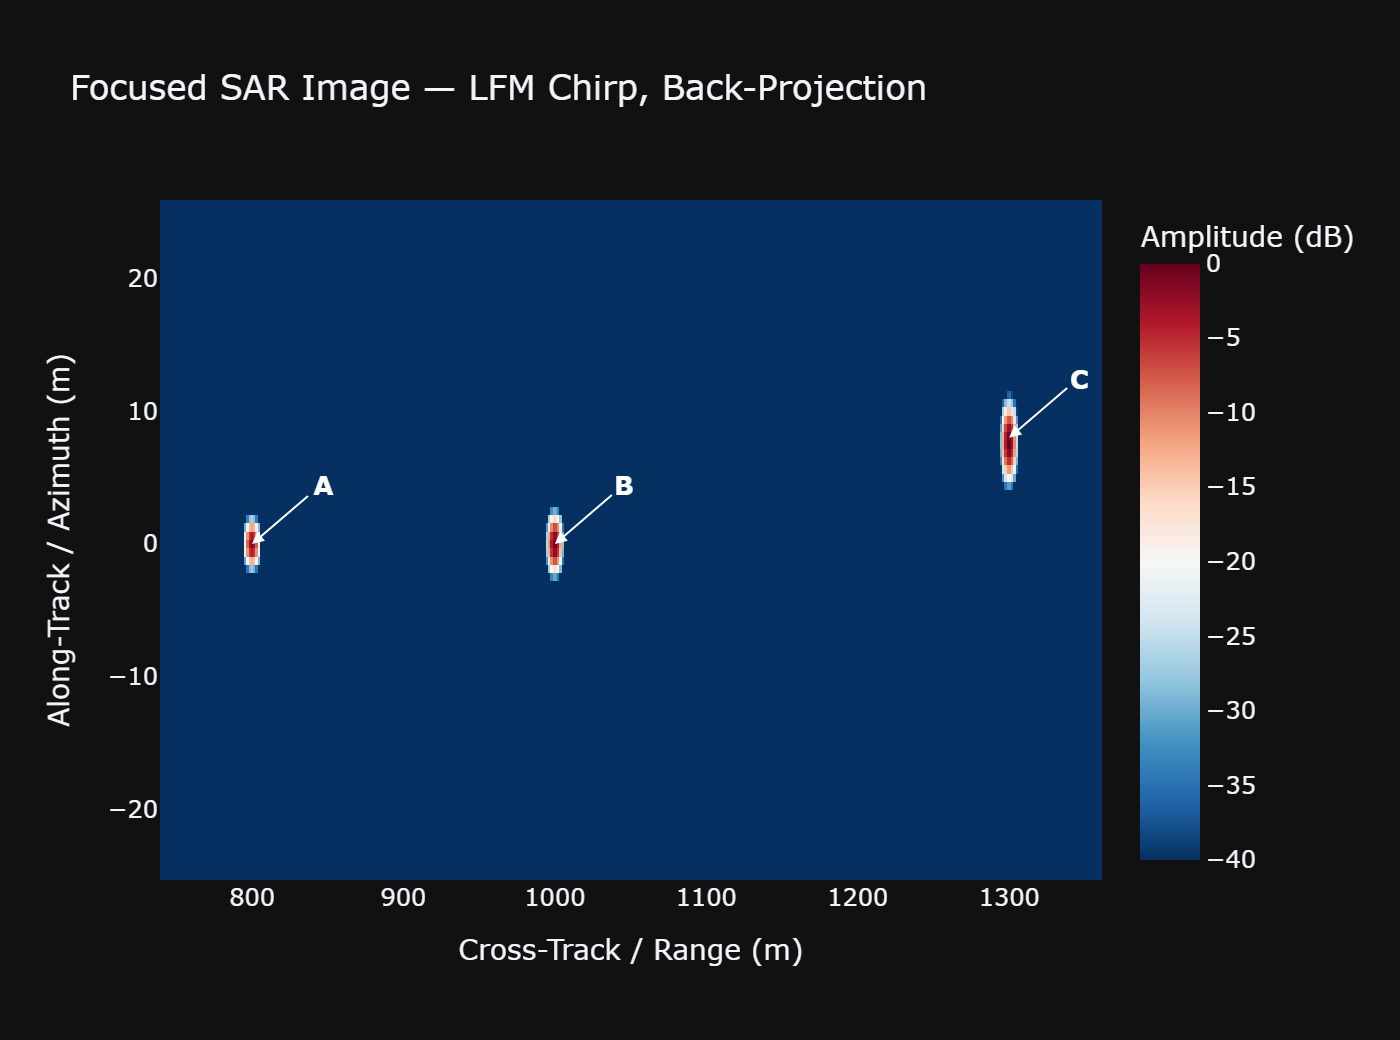

In [21]:
sar_amp_db = 20 * np.log10(np.abs(sar_image) + 1e-12)
sar_amp_db -= sar_amp_db.max()  # normalise to 0 dB

fig = go.Figure()
fig.add_trace(
    go.Heatmap(
        x=img_ranges,
        y=img_az,
        z=sar_amp_db,
        colorscale="RdBu_r",
        colorbar=dict(title="Amplitude (dB)"),
        zmin=-40,
        zmax=0,
    )
)

for tgt, lbl in zip(targets, ["A", "B", "C"]):
    x_t, y_t, _ = tgt["location"]
    fig.add_annotation(
        x=y_t,
        y=x_t,
        text=f"<b>{lbl}</b>",
        showarrow=True,
        arrowhead=2,
        arrowcolor="white",
        font=dict(color="white", size=13),
        arrowsize=1.2,
        ax=35,
        ay=-30,
    )

fig.update_layout(
    title="Focused SAR Image — LFM Chirp, Back-Projection",
    xaxis_title="Cross-Track / Range (m)",
    yaxis_title="Along-Track / Azimuth (m)",
    template="plotly_dark",
    height=520,
)
show(fig)

## Summary

This notebook demonstrated a complete **C-band stripmap LFM SAR simulation** using `RadarSimPy`, modelled on the MathWorks stripmap SAR example:

| Stage | Key Parameters | Result |
|---|---|---|
| Waveform design | $f_c$ = 4 GHz, B = 50 MHz, τ = 3 μs, PRF = 1 kHz | LFM chirp, $\Delta R$ = 3 m, Bτ = 150 (≈21.8 dB gain) |
| Radar hardware | 1 m antenna, wide cos⁸/cos⁴⁰ patterns, 40 dBm TX | fs = 400 MHz (sized for absolute-range beat, not just B) |
| Platform / scene | v = 100 m/s, 300 pulses, 3 point targets at 800/1000/1300 m | Aperture ≈ 30 m |
| Range compression | Fast-time FFT (Chebyshev window) | $\Delta R$ = 3 m, ≈−50 dB range sidelobes |
| Image formation | Back-Projection + Taylor window | $\Delta_{az}$ ≈ 1.25 m (achieved), all targets focused |

### LFM vs. Rectangular Pulse (`waveform_pulse_sar.ipynb`)

The companion rectangular-pulse notebook samples the **full PRP** and range-compresses via a **time-domain matched filter**. This LFM notebook instead relies on RadarSimPy's **stretch/deramp receiver model** for chirp waveforms: each pulse's baseband record is already a beat-tone whose length equals only the chirp duration, and range compression reduces to a **fast-time FFT** — exactly like FMCW range processing. The trade-off is that the sample rate must be chosen high enough to keep the *absolute*-range beat frequency unambiguous.

### Possible Extensions

- Implement the **Range Migration Algorithm (ω-k)** from the MathWorks example and compare focusing accuracy/speed against Back-Projection.
- Add **thermal noise** and study the SNR improvement from the ≈21.8 dB matched-filter gain vs. an unmodulated pulse of the same duration.
- Vary the **time-bandwidth product** ($B$, $\tau$) to see the range-resolution vs. energy trade-off directly.
- Extend to a **spotlight SAR** mode by steering the antenna beam to track a fixed scene patch, increasing the effective integration angle beyond the real-beam footprint.